<a href="https://colab.research.google.com/github/aristidekanamugire/Mini-Project-8/blob/main/Flood_Area_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install Libraries

In [ ]:
!pip install segmentation-models tensorflow opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 6.4 MB/s eta 0:00:00


Import Libraries

In [ ]:
import os
os.environ["SM_FRAMEWORK"] = "tf.keras" # Set Keras backend for segmentation_models
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

from tensorflow.keras import backend as K
from tensorflow.keras.optimizers import Adam

import segmentation_models as sm

Segmentation Models: using `tf.keras` framework.


Mount Google Drive

Define Dataset Paths

In [ ]:
import kagglehub

# Download latest version
DATASET_PATH = kagglehub.dataset_download("faizalkarim/flood-area-segmentation")

print("Path to dataset files:", DATASET_PATH)

IMAGE_PATH = os.path.join(DATASET_PATH, "Image")
MASK_PATH = os.path.join(DATASET_PATH, "Mask")

IMG_SIZE = 640

Using Colab cache for faster access to the 'flood-area-segmentation' dataset.
Path to dataset files: /kaggle/input/flood-area-segmentation


Load Image Paths

In [ ]:
images = sorted(os.listdir(IMAGE_PATH))
masks = sorted(os.listdir(MASK_PATH))

image_paths = [os.path.join(IMAGE_PATH,i) for i in images]
mask_paths = [os.path.join(MASK_PATH,i) for i in masks]

print("Total Images:",len(image_paths))

Total Images: 290


Image Preprocessing Functions

In [ ]:
def load_image(path):

    img = cv2.imread(path)
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
    img = img/255.0

    return img


def load_mask(path):

    mask = cv2.imread(path,0)
    mask = cv2.resize(mask,(IMG_SIZE,IMG_SIZE))

    mask = mask/255.0
    mask = (mask > 0.5).astype(np.float32)

    mask = np.expand_dims(mask,-1)

    return mask

Load Dataset

In [ ]:
X=[]
Y=[]

for img,mask in zip(image_paths,mask_paths):

    X.append(load_image(img))
    Y.append(load_mask(mask))

X=np.array(X)
Y=np.array(Y)

print(X.shape,Y.shape)

(290, 640, 640, 3) (290, 640, 640, 1)


In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_temp,Y_train,Y_temp = train_test_split(
    X,Y,test_size=0.30,random_state=42)

X_val,X_test,Y_val,Y_test = train_test_split(
    X_temp,Y_temp,test_size=0.50,random_state=42)

print("Train:",X_train.shape)
print("Validation:",X_val.shape)
print("Test:",X_test.shape)

Train: (203, 640, 640, 3)
Validation: (43, 640, 640, 3)
Test: (44, 640, 640, 3)


Train / Validation / Test Split

Data Augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([

tf.keras.layers.RandomFlip("horizontal"),
tf.keras.layers.RandomRotation(0.2),
tf.keras.layers.RandomZoom(0.2),
tf.keras.layers.RandomContrast(0.2),
tf.keras.layers.RandomBrightness(0.2)

])

Dice Metric

In [ ]:
def dice_coef(y_true,y_pred):

    smooth=1

    y_true=tf.reshape(y_true,[-1])
    y_pred=tf.reshape(y_pred,[-1])

    intersection=tf.reduce_sum(y_true*y_pred)

    return (2*intersection+smooth)/(tf.reduce_sum(y_true)+tf.reduce_sum(y_pred)+smooth)

IoU Metric

In [ ]:
def iou_metric(y_true,y_pred):

    y_pred=tf.cast(y_pred>0.5,tf.float32)

    intersection=tf.reduce_sum(y_true*y_pred)
    union=tf.reduce_sum(y_true)+tf.reduce_sum(y_pred)-intersection

    return intersection/(union+1e-7)

BCE + Dice Loss

In [ ]:
def bce_dice_loss(y_true,y_pred):

    bce = tf.keras.losses.binary_crossentropy(y_true,y_pred)
    dice = 1 - dice_coef(y_true,y_pred)

    return bce + dice

Build U-Net Model

In [ ]:
model = sm.Unet(
    "resnet34",
    encoder_weights="imagenet",
    input_shape=(IMG_SIZE,IMG_SIZE,3),
    classes=1,
    activation="sigmoid"
)

85521592/85521592 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Compile Model

In [ ]:
model.compile(

optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),

loss=bce_dice_loss,

metrics=[dice_coef,iou_metric]

)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ data (InputLayer)   │ (None, 640, 640,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_data             │ (None, 640, 640,  │          9 │ data[0][0]        │
│ (BatchNormalizatio… │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 646, 646,  │          0 │ bn_data[0][0]     │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv0 (Conv2D)      │ (None, 320, 320,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn0                 │ (None, 320, 320,  │        256 │ conv0[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu0 (Activation)  │ (None, 320, 320,  │          0 │ bn0[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 322, 322,  │          0 │ relu0[0][0]       │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pooling0            │ (None, 160, 160,  │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_bn1    │ (None, 160, 160,  │        256 │ pooling0[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_relu1  │ (None, 160, 160,  │          0 │ stage1_unit1_bn1… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 162, 162,  │          0 │ stage1_unit1_rel… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_conv1  │ (None, 160, 160,  │     36,864 │ zero_padding2d_2… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_bn2    │ (None, 160, 160,  │        256 │ stage1_unit1_con… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_relu2  │ (None, 160, 160,  │          0 │ stage1_unit1_bn2… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, 162, 162,  │          0 │ stage1_unit1_rel… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_conv2  │ (None, 160, 160,  │     36,864 │ zero_padding2d_3… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_unit1_sc     │ (None, 160, 160,  │      4,096 │ stage1_unit1_rel

 Total params: 24,456,154 (93.29 MB)

 Trainable params: 24,438,804 (93.23 MB)

 Non-trainable params: 17,350 (67.77 KB)

Callbacks

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks=[

EarlyStopping(
    patience=10,
    restore_best_weights=True
),

ReduceLROnPlateau(
    factor=0.3,
    patience=5
),

ModelCheckpoint(
    "best_unet_model.h5",
    save_best_only=True
)

]

Train Model (≥20 epochs)

In [ ]:
history = model.fit(

X_train, Y_train,
validation_data=(X_val, Y_val),
epochs=30,
batch_size=1,
callbacks=callbacks

)

Epoch 1/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - dice_coef: 0.5516 - iou_metric: 0.4916 - loss: 1.0039

203/203 ━━━━━━━━━━━━━━━━━━━━ 106s 232ms/step - dice_coef: 0.5520 - iou_metric: 0.4920 - loss: 1.0031 - val_dice_coef: 0.5578 - val_iou_metric: 0.4116 - val_loss: 4.0741 - learning_rate: 1.0000e-04
Epoch 2/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 30s 148ms/step - dice_coef: 0.7406 - iou_metric: 0.7293 - loss: 0.5879 - val_dice_coef: 0.5569 - val_iou_metric: 0.4117 - val_loss: 4.2318 - learning_rate: 1.0000e-04
Epoch 3/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - dice_coef: 0.7890 - iou_metric: 0.7953 - loss: 0.4552

203/203 ━━━━━━━━━━━━━━━━━━━━ 42s 205ms/step - dice_coef: 0.7890 - iou_metric: 0.7953 - loss: 0.4552 - val_dice_coef: 0.5634 - val_iou_metric: 0.4259 - val_loss: 1.5920 - learning_rate: 1.0000e-04
Epoch 4/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - dice_coef: 0.8151 - iou_metric: 0.8013 - loss: 0.4233

203/203 ━━━━━━━━━━━━━━━━━━━━ 59s 289ms/step - dice_coef: 0.8151 - iou_metric: 0.8014 - loss: 0.4231 - val_dice_coef: 0.6145 - val_iou_metric: 0.4658 - val_loss: 1.4563 - learning_rate: 1.0000e-04
Epoch 5/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - dice_coef: 0.8492 - iou_metric: 0.8362 - loss: 0.3430

203/203 ━━━━━━━━━━━━━━━━━━━━ 94s 465ms/step - dice_coef: 0.8492 - iou_metric: 0.8362 - loss: 0.3430 - val_dice_coef: 0.7383 - val_iou_metric: 0.6938 - val_loss: 0.6578 - learning_rate: 1.0000e-04
Epoch 6/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - dice_coef: 0.8469 - iou_metric: 0.8264 - loss: 0.3418

203/203 ━━━━━━━━━━━━━━━━━━━━ 107s 526ms/step - dice_coef: 0.8469 - iou_metric: 0.8264 - loss: 0.3416 - val_dice_coef: 0.8072 - val_iou_metric: 0.7566 - val_loss: 0.4706 - learning_rate: 1.0000e-04
Epoch 7/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 30s 147ms/step - dice_coef: 0.8702 - iou_metric: 0.8533 - loss: 0.2939 - val_dice_coef: 0.7882 - val_iou_metric: 0.7217 - val_loss: 0.5221 - learning_rate: 1.0000e-04
Epoch 8/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 30s 149ms/step - dice_coef: 0.8870 - iou_metric: 0.8635 - loss: 0.2620 - val_dice_coef: 0.7782 - val_iou_metric: 0.6978 - val_loss: 0.5975 - learning_rate: 1.0000e-04
Epoch 9/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 30s 150ms/step - dice_coef: 0.8897 - iou_metric: 0.8698 - loss: 0.2444 - val_dice_coef: 0.8119 - val_iou_metric: 0.7435 - val_loss: 0.4828 - learning_rate: 1.0000e-04
Epoch 10/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - dice_coef: 0.9025 - iou_metric: 0.8783 - loss: 0.2228

203/203 ━━━━━━━━━━━━━━━━━━━━ 108s 532ms/step - dice_coef: 0.9025 - iou_metric: 0.8783 - loss: 0.2227 - val_dice_coef: 0.8194 - val_iou_metric: 0.7516 - val_loss: 0.4649 - learning_rate: 1.0000e-04
Epoch 11/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 30s 149ms/step - dice_coef: 0.8970 - iou_metric: 0.8713 - loss: 0.2312 - val_dice_coef: 0.8145 - val_iou_metric: 0.7298 - val_loss: 0.5435 - learning_rate: 1.0000e-04
Epoch 12/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 30s 150ms/step - dice_coef: 0.9255 - iou_metric: 0.9001 - loss: 0.1808 - val_dice_coef: 0.8342 - val_iou_metric: 0.7596 - val_loss: 0.4697 - learning_rate: 1.0000e-04
Epoch 13/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - dice_coef: 0.9149 - iou_metric: 0.8909 - loss: 0.1949

203/203 ━━━━━━━━━━━━━━━━━━━━ 106s 525ms/step - dice_coef: 0.9149 - iou_metric: 0.8910 - loss: 0.1949 - val_dice_coef: 0.8410 - val_iou_metric: 0.7708 - val_loss: 0.4463 - learning_rate: 1.0000e-04
Epoch 14/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 30s 148ms/step - dice_coef: 0.9366 - iou_metric: 0.9167 - loss: 0.1521 - val_dice_coef: 0.8146 - val_iou_metric: 0.7253 - val_loss: 0.6014 - learning_rate: 1.0000e-04
Epoch 15/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 30s 149ms/step - dice_coef: 0.9272 - iou_metric: 0.9035 - loss: 0.1656 - val_dice_coef: 0.8272 - val_iou_metric: 0.7545 - val_loss: 0.4651 - learning_rate: 1.0000e-04
Epoch 16/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 31s 151ms/step - dice_coef: 0.9264 - iou_metric: 0.9000 - loss: 0.1649 - val_dice_coef: 0.8255 - val_iou_metric: 0.7583 - val_loss: 0.4592 - learning_rate: 1.0000e-04
Epoch 17/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 31s 151ms/step - dice_coef: 0.9309 - iou_metric: 0.9060 - loss: 0.1577 - val_dice_coef: 0.8336 - val_iou_metric: 0.7626 - val_loss: 0.4586

Training Visualization

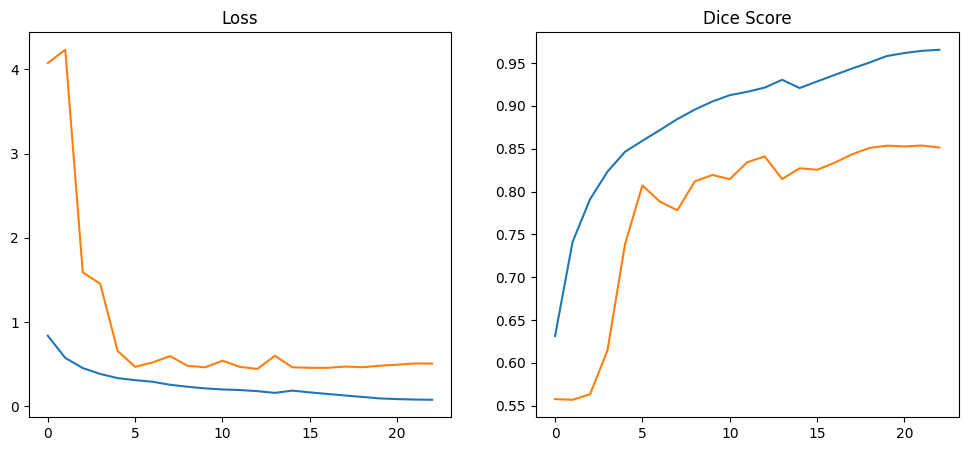

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history.history["dice_coef"])
plt.plot(history.history["val_dice_coef"])
plt.title("Dice Score")

plt.show()

Evaluate Model

In [ ]:
results=model.evaluate(X_test,Y_test)

print("Test Loss:",results[0])
print("Dice Score:",results[1])
print("IoU:",results[2])

2/2 ━━━━━━━━━━━━━━━━━━━━ 72s 22s/step - dice_coef: 0.8755 - iou_metric: 0.8078 - loss: 0.3746
Test Loss: 0.3748829662799835
Dice Score: 0.8767030239105225
IoU: 0.8096160888671875


Prediction Visualization

In [ ]:
def visualize_predictions(model,X,Y,n=6):

    idx=np.random.randint(0,len(X),n)

    for i in idx:

        img=X[i]
        true_mask=Y[i]

        pred=model.predict(img[np.newaxis,...])[0]
        pred=(pred>0.5).astype(np.float32)

        error=np.abs(true_mask-pred)

        plt.figure(figsize=(16,4))

        plt.subplot(1,4,1)
        plt.imshow(img)
        plt.title("Image")

        plt.subplot(1,4,2)
        plt.imshow(true_mask.squeeze(),cmap="gray")
        plt.title("Ground Truth")

        plt.subplot(1,4,3)
        plt.imshow(pred.squeeze(),cmap="gray")
        plt.title("Prediction")

        plt.subplot(1,4,4)
        plt.imshow(error.squeeze(),cmap="hot")
        plt.title("Error Map")

        plt.show()

Show 6 Results

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


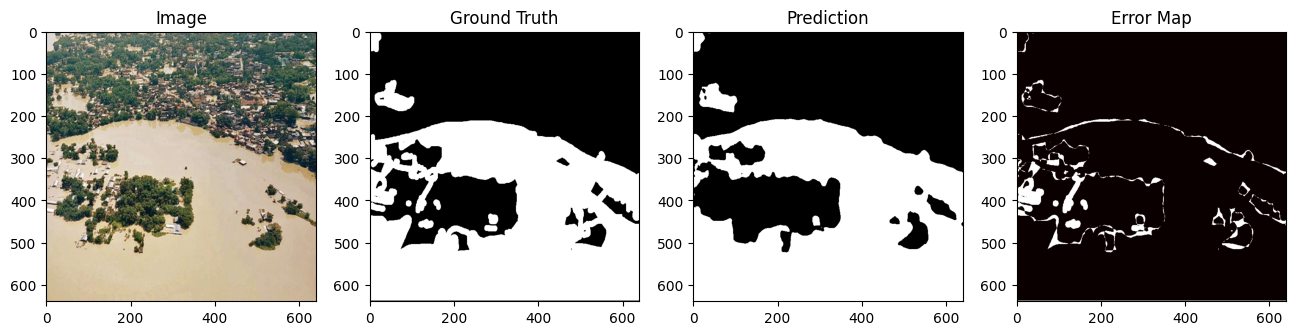

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


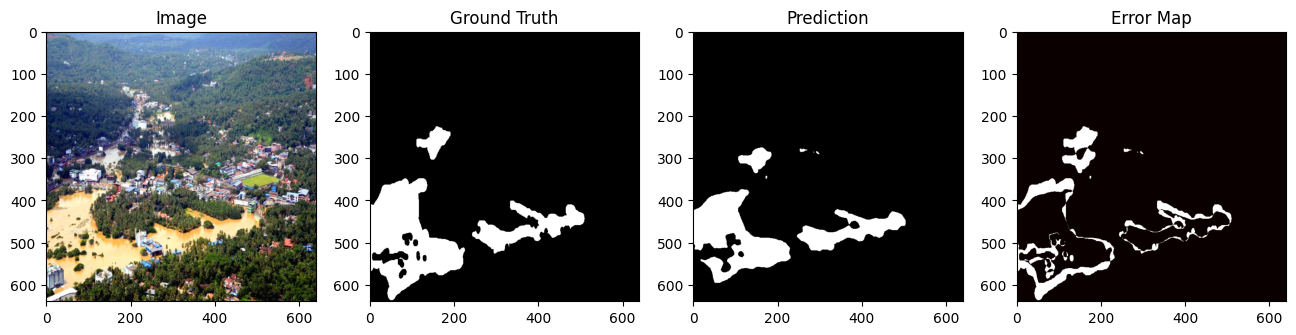

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


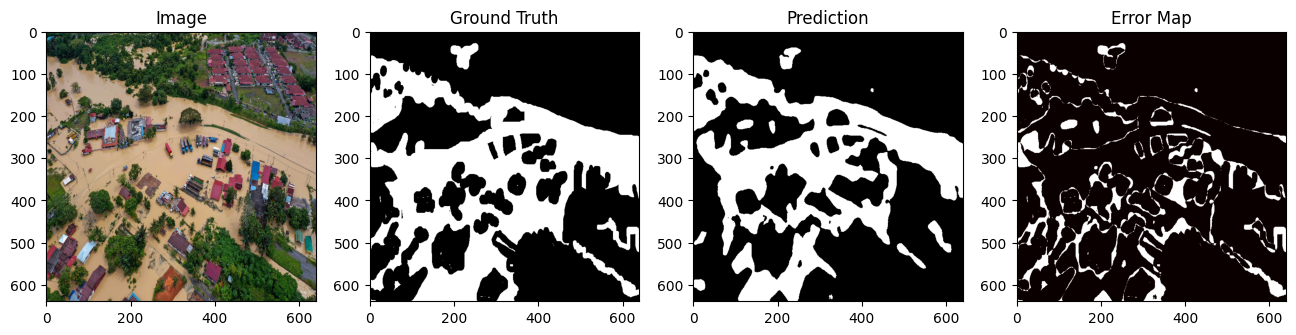

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


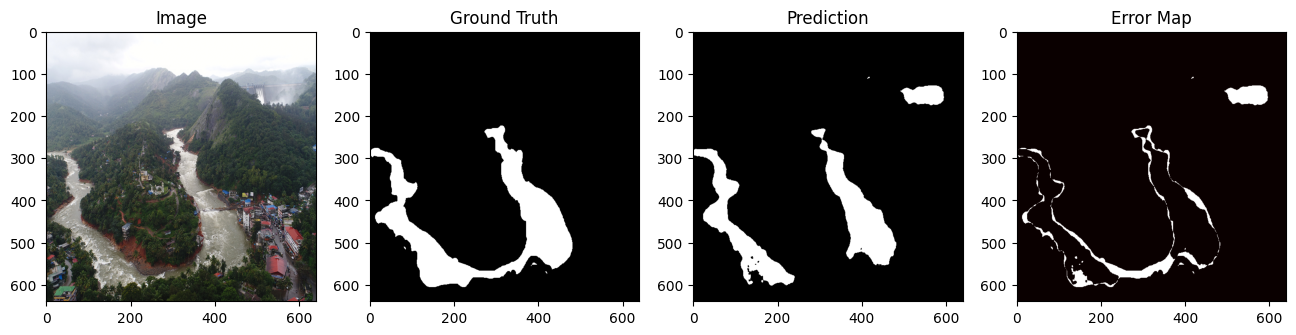

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


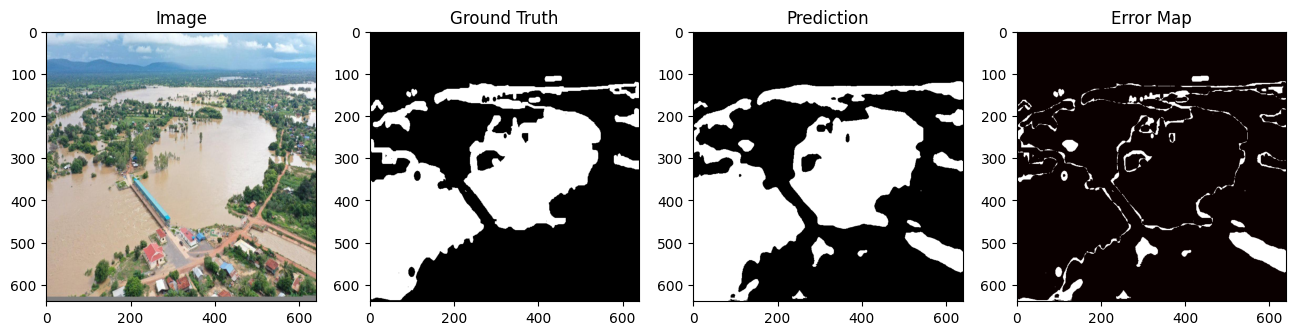

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


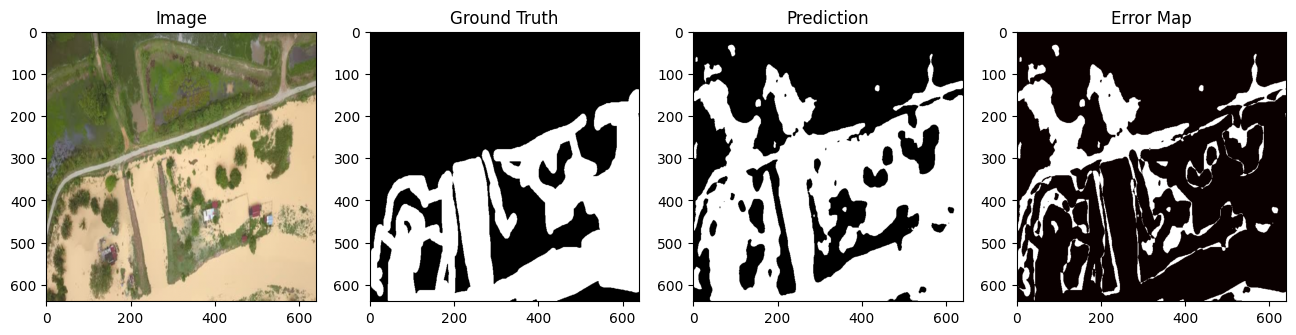

In [ ]:
visualize_predictions(model,X_test,Y_test,6)

Save Model

In [ ]:
model.save("flood_segmentation_unet.h5")